In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data_dir = "dataset"

img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 11623 files belonging to 7 classes.
Using 9299 files for training.
Found 11623 files belonging to 7 classes.
Using 2324 files for validation.
Classes: ['Damaged_Infrastructure', 'Drought', 'Fire_Disaster', 'Human_Damage', 'Land_Slide', 'Non_Damage', 'Water_Disaster']


In [3]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [4]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [8]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    # ✅ 6 classes (IMPORTANT)
    layers.Dense(7, activation='softmax')
])

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5)

Epoch 1/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 270s 875ms/step - accuracy: 0.9166 - loss: 0.2904 - val_accuracy: 0.9531 - val_loss: 0.1420
Epoch 2/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 261s 898ms/step - accuracy: 0.9594 - loss: 0.1240 - val_accuracy: 0.9565 - val_loss: 0.1232
Epoch 3/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 274s 939ms/step - accuracy: 0.9673 - loss: 0.0957 - val_accuracy: 0.9574 - val_loss: 0.1181
Epoch 4/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 242s 832ms/step - accuracy: 0.9739 - loss: 0.0758 - val_accuracy: 0.9634 - val_loss: 0.1176
Epoch 5/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 254s 874ms/step - accuracy: 0.9766 - loss: 0.0668 - val_accuracy: 0.9617 - val_loss: 0.1152


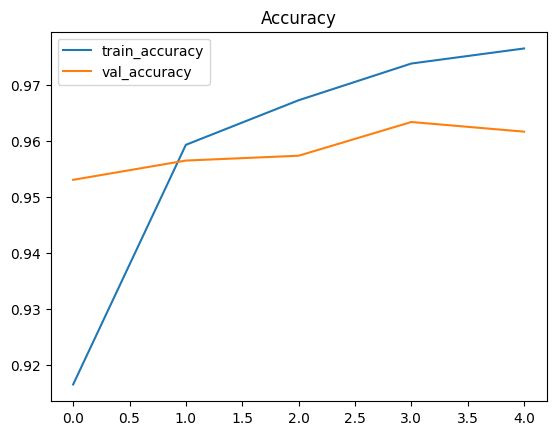

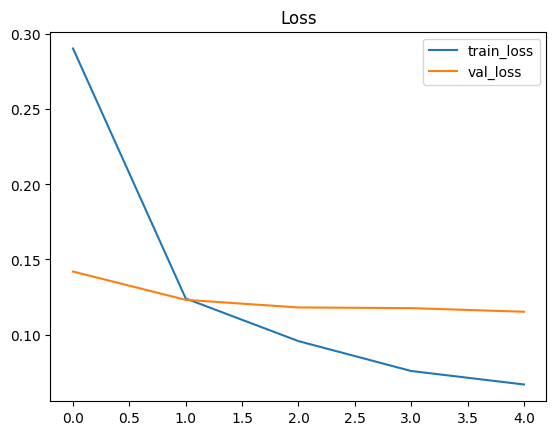

In [11]:
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()

In [12]:
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)

    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    predictions = model.predict(img_array)[0]

    predicted_index = np.argmax(predictions)
    confidence = float(np.max(predictions))

    predicted_class = class_names[predicted_index]

    # 🔥 DISASTER SCORE LOGIC
    if predicted_class == "Non_Damage":
        disaster_score = 1 - confidence
    else:
        disaster_score = confidence

    print("Class:", predicted_class)
    print("Confidence:", confidence)
    print("Disaster Score:", disaster_score)

In [13]:
predict_image("fire.jpg")  # change path

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Class: Fire_Disaster
Confidence: 0.7913525700569153
Disaster Score: 0.7913525700569153


In [14]:
model.save("disaster_CNN_model.keras")
print("✅ Model saved successfully!")

✅ Model saved successfully!
